c:\Users\richa\Downloads\Predictive Maintenance\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Artifacts loaded successfully.
Model expects these 9 features: ['Air_Temp', 'Process_Temp', 'Rotational_Speed', 'Torque', 'Tool_Wear', 'Type_Encoded', 'Temp_Delta', 'Power_W', 'Risk_Heuristic']
Using encoding map: {'L': 0, 'M': 1, 'H': 2}
Data re-loaded. Ready to explain 2000 samples.


c:\Users\richa\Downloads\Predictive Maintenance\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


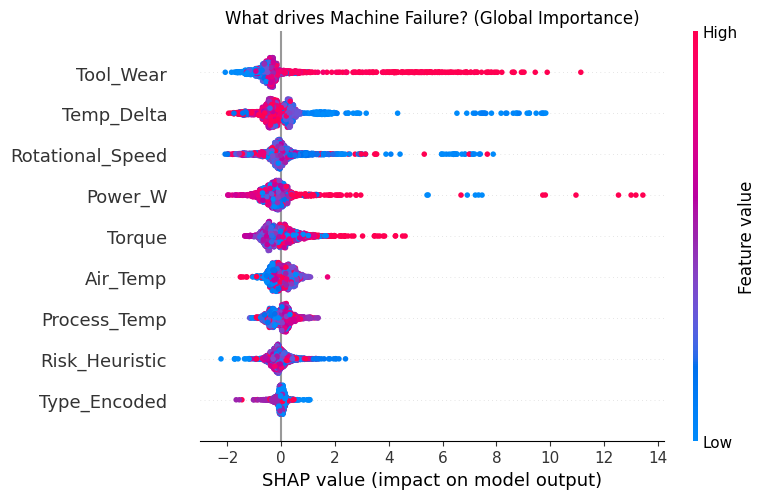

In [1]:

import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. LOAD THE BRAIN (The .pkl file)
# We load the dictionary we saved in Day 5
artifact = joblib.load('../data/processed/predictive_maintenance_model.pkl')
lgb_model = artifact['model']
feature_cols = artifact['features'] # <--- Loaded from file!
type_map = artifact['type_map']     # <--- Loaded from file!

print("Artifacts loaded successfully.")
print(f"Model expects these {len(feature_cols)} features: {feature_cols}")
print(f"Using encoding map: {type_map}")

# 2. LOAD THE DATA (The CSV)
# We need to recreate X_test so the model has something to look at.
df = pd.read_csv('../data/processed/ai4i2020_featured.csv')

# Use the LOADED map (No manual typing)
df['Type_Encoded'] = df['Product_Type'].map(type_map)

# Use the LOADED feature list
X = df[feature_cols]
y = df['Machine_Failure']

# Re-split to get the Test Set (Using random_state=42 ensures it matches Day 5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data re-loaded. Ready to explain {len(X_test)} samples.")

# 3. RE-SPLIT (To get X_test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. RUN SHAP
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

# 5. VISUALIZE
plt.title("What drives Machine Failure? (Global Importance)")
if isinstance(shap_values, list):
    # Old behavior (List of 2 arrays)
    shap.summary_plot(shap_values[1], X_test, plot_type="dot")
else:
    # New behavior (Single array for positive class)
    shap.summary_plot(shap_values, X_test, plot_type="dot")

The "Executive Summary" Pitch
When you present this to the "Client" (or in your portfolio video), here is your script:

*"Our model doesn't just guess; it understands the physics of failure.

The Primary Driver is Tool Wear: We can now predict exactly when a tool becomes unsafe, allowing you to schedule replacements during lunch breaks instead of waiting for a crash.

The Hidden Killer is Heat Efficiency (Temp Delta): The AI detected that Inefficient Cooling is the second biggest cause of downtime. This allows us to spot blocked vents or failing fans weeks before the motor burns out.

The Operator Guide (Speed): We identified a dangerous 'Stall Zone' at low speeds. The model now flags this instantly."*